Subway Points

In [1]:
import geopandas as gpd
from shapely.validation import make_valid

IN_PATH  = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/Data/MTA_Subway_Stations_20260723.geojson"
OUT_PATH = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/outputs/subway_stops.geojson"

gdf = gpd.read_file(IN_PATH)
gdf = gdf[gdf["borough"].isin(["Bk", "Q"])]
gdf["geometry"] = gdf.geometry.apply(lambda g: make_valid(g) if g is not None else g)
gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty]

print(f"Exporting {len(gdf)} stations")
gdf.to_file(OUT_PATH, driver="GeoJSON")
print("Done.")

Exporting 252 stations
Done.


Centerline

In [2]:
import json, re

IN_PATH  = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/Data/Centerline_20260723.geojson"
OUT_PATH = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/outputs/Centerline.geojson"

with open(IN_PATH, "r", encoding="utf-8") as f:
    raw = f.read()

# Show whats broken
char = 16073177
print(repr(raw[char-200 : char+200]))

# Fix NaN/Infinity values
raw_fixed = re.sub(r'\bNaN\b', 'null', raw)
raw_fixed = re.sub(r'\bInfinity\b', 'null', raw_fixed)

# Parse and re-export clean
geojson = json.loads(raw_fixed)
with open(OUT_PATH, "w", encoding="utf-8") as f:
    json.dump(geojson, f)

print("Done.")

'0","snow_priority":"C","joinid":null,"bphys_id":null,"carto_display_level":null,"number_travel_lanes":"2","number_park_lanes":"2","number_total_lanes":"4","pre_modifier":null,"pre_directional":null,"post_directional":null,"post_modifier":null,"full_street_name":"CLOVE RD","bike_trafdir":null,"shape_length":"36.88032831955433","globalid":"98a75d66-999b-48ce-b770-0edc2014c701","segment_type":null,"s'


Done.


In [3]:
import geopandas as gpd
import requests
import json
from shapely.validation import make_valid

OUT_PATH = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/outputs/Centerline.geojson"

# Socrata API with borough filter - 3=Brooklyn, 4=Queens
url = "https://data.cityofnewyork.us/resource/inkn-q76z.geojson"
params = {
    "$where": "boroughcode IN('3','4')",
    "$limit": 500000
}

print("Downloading...")
r = requests.get(url, params=params)
geojson = r.json()
print(f"Features received: {len(geojson['features'])}")

gdf = gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
gdf["geometry"] = gdf.geometry.apply(lambda g: make_valid(g) if g is not None else g)
gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty]

print(f"Exporting {len(gdf)} segments")
gdf.to_file(OUT_PATH, driver="GeoJSON")
print("Done.")


Downloading...


Features received: 72926


Exporting 72926 segments


Done.


Features: 72926
CRS: EPSG:4326
Bounds: [-74.05611418  40.51412936 -73.70002141  40.80539404]
Columns: ['stname_label', 'rw_type', 'segment_type_value', 'l_low_hn', 'sandist_ind', 'bphys_id', 'pre_directional', 'rsubsect', 'number_park_lanes', 'avgtravtime', 'borough_indicator', 'created_date', 'r_zip', 'r_low_hn', 'bike_lane', 'nominaldir', 'post_type', 'rwjurisdiction', 'joinid', 'nonped', 'l_blockfaceid', 'pre_type', 'post_directional', 'collectionmethod', 'fire_lane', 'objectid', 'globalid', 'segment_type', 'street_name', 'within_bndy_dist', 'truck_route_type', 'b5sc', 'full_street_name', 'shape_length', 'streetwidth_irr', 'status', 'posted_speed', 'carto_display_level', 'r_high_hn', 'l_zip', 'segmentlength', 'streetwidth', 'lsubsect', 'special_disaster', 'r_blockfaceid', 'fcc', 'boroughcode', 'to_level_code', 'post_modifier', 'pre_modifier', 'bike_trafdir', 'continuous_parity_flag', 'trafdir', 'number_total_lanes', 'twisted_parity_flag', 'snow_priority', 'modified_date', 'number_tr

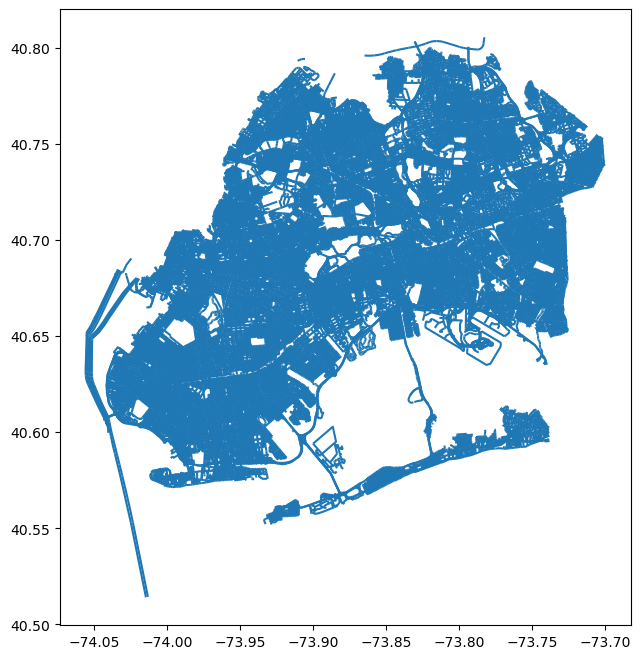

In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt

OUT_PATH = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/outputs/Centerline.geojson"

gdf = gpd.read_file(OUT_PATH)

print(f"Features: {len(gdf)}")
print(f"CRS: {gdf.crs}")
print(f"Bounds: {gdf.total_bounds}")
print(f"Columns: {gdf.columns.tolist()}")

gdf.plot(figsize=(8,8))
plt.show()

In [5]:
import geopandas as gpd
from shapely.validation import make_valid

IN_PATH  = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/outputs/Centerline.geojson"
OUT_PATH = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/outputs/Centerline.geojson"
BEDSTUY_PATH = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/Data/boundary_bedstuy.geojson"
JACKSON_PATH = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/Data/boundary_jacksonheights.geojson"

RADIUS_FT = 5280  # 1 mile, boundary files are already in EPSG:2263 (feet)

bedstuy = gpd.read_file(BEDSTUY_PATH)
jackson = gpd.read_file(JACKSON_PATH)

# NOTE: to_crs() returns a new GeoDataFrame, it does not modify in place.
# Buffering here (in EPSG:2263, feet) rather than after reprojecting to
# EPSG:4326 (degrees) avoids buffering by "5280 degrees".
study_area = gpd.GeoSeries(
    [bedstuy.geometry.iloc[0].buffer(RADIUS_FT), jackson.geometry.iloc[0].buffer(RADIUS_FT)],
    crs=bedstuy.crs,
).union_all()

cl = gpd.read_file(IN_PATH)
cl_2263 = cl.to_crs(bedstuy.crs)
cl_2263 = cl_2263[cl_2263.geometry.intersects(study_area)]

cl_2263["geometry"] = cl_2263.geometry.apply(lambda g: make_valid(g) if g is not None else g)
cl_2263 = cl_2263[cl_2263.geometry.notna() & ~cl_2263.geometry.is_empty]

cl_out = cl_2263.to_crs("EPSG:4326")

print(f"Exporting {len(cl_out)} segments")
cl_out.to_file(OUT_PATH, driver="GeoJSON")
print("Done.")

Exporting 10531 segments


Done.


## Splitting into per-neighborhood centerlines

The file above still covers both neighborhoods combined within a 1-mile buffer, which is why it's still large enough to trip up Grasshopper's GeoJSON reader. Reuse `cl_2263` (already validated/repaired above) and clip it to each neighborhood's actual boundary — not the buffer — then export separately so Grasshopper only has to load what it needs at a time.

In [ ]:
BEDSTUY_OUT = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/outputs/centerline_bedstuy.geojson"
JACKSON_OUT = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/outputs/centerline_jacksonheights.geojson"

for boundary, out_path, label in [
    (bedstuy, BEDSTUY_OUT, "bedstuy"),
    (jackson, JACKSON_OUT, "jacksonheights"),
]:
    clipped = gpd.clip(cl_2263, boundary)
    clipped = clipped.to_crs("EPSG:4326")
    print(f"{label}: {len(clipped)} segments -> {out_path}")
    clipped.to_file(out_path, driver="GeoJSON")